# Анализ данных

Скачаем необходимые библиотеки



In [1]:
!pip install -q category-encoders lifelines optuna optuna-integration prince scikit-survival

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 111.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 20.7 MB/s eta 0:00:00


Импортируем необходимые библиотеки

In [183]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

from category_encoders import CatBoostEncoder, CountEncoder

from sklearn.decomposition import PCA, KernelPCA
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from shap import TreeExplainer, summary_plot

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

from scipy.integrate import trapezoid
from scipy.stats import norm

from prince import FAMD, MCA

from sksurv.metrics import (
    as_concordance_index_ipcw_scorer,
    as_cumulative_dynamic_auc_scorer,
    as_integrated_brier_score_scorer,
    concordance_index_censored,
    concordance_index_ipcw,
    cumulative_dynamic_auc,
    integrated_brier_score
)
from sksurv.util import Surv

from xgboost import XGBRegressor

import optuna
from optuna.distributions import IntDistribution, FloatDistribution
from optuna_integration import OptunaSearchCV

import random

from tqdm.auto import tqdm

random_state = 42

Скачаем данные по клиентам телекомпании

In [4]:
df = pd.read_csv('Telco-Customer-Churn.csv', index_col=0)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No


Итак, в данных есть седующие признаки:
- Gender - Пол субъекта
- SeniorCitizen - Является ли субъект городскии жителем
- Partner - Есть ли у субъекта партнёр
- Dependents - Есть ли у субъекта зависмые от него люди
- tenure - сколько субъект является ли клиентом телекомпании
- PhoneService - подключена ли телефонная связь в тарифный план клиента
- MultipleLines - подключено ли у клиента несколько телефнных линий (отмечено отдкльно, если у клиента не подключена телефонная связь)
- InternetServie - какой тип интернета подключён у клиента (DSL, оптоволокно) (отмечено отдельно, если у клиента не подключён интернет)
- OnlineSecirity - подключена ли у клиента опция онлайн-безопасности (отмечено отдельно, если у клиента не подключён интернет)
- OnlineBackup - подключена ли у клиента опция онлайн-бэкапа (отмечено отдельно, если у клиента не подключён интернет)
- DeviceProtection - подключена ли у клиента опция защиты девайсов (отмечено отдельно, если у клиента не подключён интернет)
- TechSupport - подключена ли у клиента опция техподдержки (отмечено отдельно, если у клиента не подключён интернет)
- StreamingTV - подключена ли у клиента опция стримингового телевидения (отмечено отдельно, если у клиента не подключён интернет)
- StreamingMovies - подключена ли у клиента опция доступа к стримингоым площадкам (отмечено отдельно, если у клиента не подключён интернет)
- Contract - тип контракта, заключённый с пользователем (помесячный, на год, на 2 года)
- Paperless billing - платит ли клиент онлайн или нет
- Payment Method - тип оплаты клиентом тарифа (чек по почте, онлайн-чек, оплата через банкомат, оплата кредитной картой)
- MonthlyCharges - сколько долларов в среднем платит клиент в месяц
- TotalCharges - сколько долларов клиент уже заплатил
- Churn - ушёл клиент или нет

Попробуем закодировать некоторые столбцы так, чтобы они стали бинарными

А заодно разделим клиентов на тех, у кого интернет есть и на тех, у кого его нет - моё предположение, что их поведение существенным образом различается

In [5]:
df = df.rename(columns={'gender': 'Gender', 'tenure': 'Tenure'})
df[['Partner', 'Dependents', 'Gender', 'Churn', 'MultipleLines']] = df[[
    'Partner', 'Dependents','Gender', 'Churn', 'MultipleLines'
]].replace({
    'Female': '0',
    'Male': '1',
    'No': '0',
    'No phone service': '-1',
    'Yes': '1'
}).astype(int)
df = df.drop(df[df['TotalCharges'] == ' '].index)
df['TotalCharges'] = df['TotalCharges'].astype(float)

df_internet, df_no_internet = (
    df[df['OnlineBackup'] != 'No internet service'],
    df[df['OnlineBackup'] == 'No internet service']
)
replace_columns = [
    'PhoneService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PaperlessBilling'
]
df_internet[replace_columns] = df_internet[replace_columns].replace({
    'No': '0',
    'Yes': '1'
}).astype(int)

df_no_internet = df_no_internet.drop(columns=[
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'InternetService',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PhoneService'
])
for column in [
    'PhoneService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]:
    replace_columns.remove(column)
replace_columns.append('MultipleLines')
df_no_internet[replace_columns] = df_no_internet[replace_columns].replace({
    'No': '0',
    'Yes': '1'
}).astype(int)

/tmp/ipykernel_5141/1498620553.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_internet[replace_columns] = df_internet[replace_columns].replace({


Итак, проведём лог-ранговый тест для проверки, действительно ли функции выживания статистически различаются у тех клиентов, у кого есть интернет, и у тех, у кого интернета нет

Сформулируем следующие гипотезы:
- Нулевая гипотеза $\large{H_0}$ - функции выживания двух групп идентичны, $\large{S_1(t)=S_2(t)}$
- Альтернативная гипотеза $\large{H_1}$ - функции выживания двух групп различаются, $\large{S_1(t) \neq S_2(t)}$

Тест работает в дискретные моменты времени $\large{t_j}$, когда происходит хотя бы одно событие. На каждом таком шаге он сравнивает наблюдаемое ($\large{O}$)
число событий в группе с ожидаемым ($\large{E}$), при условии, что нулевая гипотеза верна

Итак, пусть у нас есть 2 группы (1 и 2). В момент времени $\large{t_j}$:
- $\large{n_{1j}, n_{2j}}$ - количество объектов в группе риска в момент времени $\large{t_j}$ в группах 1 и 2. Общее число под риском - $\large{n_j=n_{1j}+n_{2j}}$
- $\large{d_{1j}, d_{2j}}$ - количество наступивших событий в момент времени $\large{t_j}$ в группах 1 и 2. Общее число наступивших событий - $\large{d_j=d_{1j}+d_{2j}}$

Если разницы между группами нет, то вероятность наступления события для объекта из группы 1 равна общей доле событий. Ожидаемое число событий в группе 1:
$$\large{e_{1j}=n_{1j}\frac{d_j}{n_j}}$$

Разность $\large{d_{1j}-e_{1j}}$ подчиняется гипергеометрическому распределению. Его дисперсия вычисляется как:
$$\large{v_j=\frac{n_{1j}n_{2j}d_j\left(n_j-d_j\right)}{n_j^2\left(n_j-1\right)}}$$

Далее суммируем разности и дисперсии по всем временам $\large{t_j}$:
$$\large{\begin{cases}U=\sum_j\left(d_{1j}-e_{1j}\right) \\ V=\sum_{j}v_j\end{cases}}$$

Тестовая статистика (Z-score) имеет стандартное нормальное распределение:
$$\large{Z=\frac{U}{\sqrt{V}} \sim \mathcal{N}(0, 1)}$$

- Если p-value < 0.05, мы отвергаем $\large{H_0}$ - кривые статистически значимо различаются
- Если p-value > 0.05, у нас нет оснований считать, что кривые разные.


In [6]:
logrank_test(
    df_internet['Tenure'],
    df_no_internet['Tenure'],
    observed_A=df_internet['Churn'],
    observed_B=df_no_internet['Churn'],
)

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
        observed_A = customerID
7590-VHVEG    0
5575-GNVDE    0
3668-QPYBK    1
7795-CFOCW    0
9237-HQITU    1
             ..
6840-RESVB    0
2234-XADUH    0
4801-JZAZL    0
8361-LTMKD    1
3186-AJIEK    0
Name: Churn, Length: 5512, dtype: int64
        observed_B = customerID
7469-LKBCI    0
8191-XWSZG    0
1680-VDCWW    0
1066-JKSGK    1
7310-EGVHZ    0
             ..
4807-IZYOZ    0
9710-NJERN    0
9837-FWLCH    0
0871-OPBXW    0
2569-WGERO    0
Name: Churn, Length: 1520, dtype: int64
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
           8.33 <0.005      8.00

Итак, p-value очень мал - меньше 0.005, то есть кривые различаются значительно

Для начала рассмотрим 3 основные функции в задаче time-to-event^
- Функция выживания $\large{S(t)}$ - показывает, сколько процентов объеков ещё не выбыло в моменту времени $\large{t}$. То есть функция оценивает вероятность, что событие ещё не произошло в момент времени $\large{t}$
$$\large{S(t)=P(T>t)}$$
- Функция мгновенного риска $\large{h(t)}$ - насколько рисковано не быть выбытым в момент времени $\large{t}$. Форма этой функции показывает динамику риска - растёт ли он со временем, постоянен или падает. Сама функция оценивает мгновенную интенсивность наступления события в момент $\large{t}$, при условии, что объект дожил до $\large{t}$
$$\large{h(t)=\lim_{\Delta t \rightarrow 0}\frac{P(t \leq T + \Delta t | T \geq t)}{\Delta t}=\frac{f(t)}{S(t)},}$$
где $\large{f(t)}$ - плотность распределения
- Функция кумулятивного риска $\large{H(t)}$ - накопительная величина - сама по себе не так интерпретируема, но крайне удобна математически. Оценивает сумму мгновенных рисков по пути
$$\large{H(t)=\int_0^th(u)du}$$

Также можно отметить связь между этими функциями:
1) $\large{S(t)=e^{-H(t)} \Leftrightarrow H(t)=-\ln S(t)}$
2) $\large{h(t)=-\frac{d\ln S(t)}{dt}=-\frac{S'(t)}{S(t)}}$

Рассмотрим непараметрическую оценку функции выживания - она не обучается в прямом смысле этого слова, а просто оценивает поданные на вход данные

Итак, пусть есть некий момент времени $\large{t_i}$, тогда веротяность его пережить равняется:
$$\large{P(T>t_i|T \geq t_i)=1-\frac{d_i}{n_i},}$$
где:
- $\large{d_i}$ - количество событий, произошедшее в момент времени $\large{t_i}$
- $\large{n_i}$ - количество объектов, доживших до момента времени $\large{t_i}$ и находящиеся соответственно в зоне риска

Тогда функция выживания оценивается как произведение всех условных вероятностей:
$$\large{\hat{S}(t)=P(T>t_1)\cdot P(T>t_2|T>t_1) \cdot ... \cdot P(T>t|T>t_{m-1})=\prod_{t_i \leq t}\left(1-\frac{d_i}{n_i}\right)}$$

Вышеописанная функция Каплана-Майера является эталоном для сранения функций выживаний различных алгоритмов

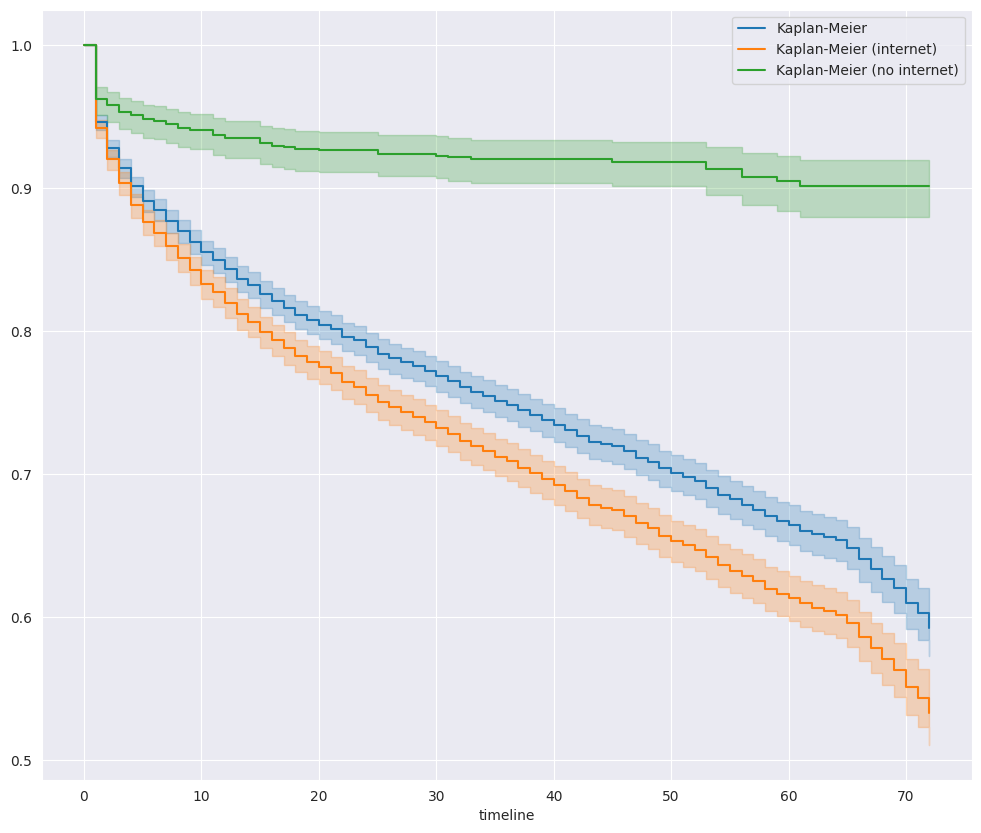

In [11]:
kmf = KaplanMeierFitter()
kmf.fit(
    df['Tenure'],
    event_observed=df['Churn'],
    label='Kaplan-Meier'
)

kmf_i = KaplanMeierFitter()
kmf_i.fit(
    df_internet['Tenure'],
    event_observed=df_internet['Churn'],
    label='Kaplan-Meier (internet)'
)

kmf_ni = KaplanMeierFitter()
kmf_ni.fit(
    df_no_internet['Tenure'],
    event_observed=df_no_internet['Churn'],
    label='Kaplan-Meier (no internet)'
)

ax = plt.subplots(figsize=(12, 6))[1]
kmf.plot_survival_function(ax=ax)
kmf_i.plot_survival_function(ax=ax)
kmf_ni.plot_survival_function(ax=ax)
plt.show()

Итак, видим, что клиенты с интернетом уходят гораздо чаще, чем клиенты без интернета. То есть при отсутствующем интернете после 2 лет обслкживания вероятность остаться - 90%, а у тех, у кого есть интернет - только 55%

То есть обрабатывать эти группы людей надо отдельно

Закодируем категориальные столбцы и нормируем данные. Пока мы это делаем чисто для визуализации

In [7]:
categorical_columns = df.select_dtypes(exclude='number').columns
df_encoded = df.copy()

encoder = CatBoostEncoder(
    cols=categorical_columns,
    random_state=random_state
)
df_encoded[categorical_columns] = encoder.fit_transform(
    df[categorical_columns],
    df['Churn']
)

scaler = StandardScaler()
df_encoded.loc[:, df_encoded.drop(columns='Churn').columns] = \
scaler.fit_transform(
    df_encoded.drop(columns='Churn')
)

/tmp/ipykernel_5141/1894371399.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.00943013  0.99065797  0.99065797 ... -1.00943013  0.99065797
  0.99065797]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_encoded.loc[:, df_encoded.drop(columns='Churn').columns] = \
/tmp/ipykernel_5141/1894371399.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.44032709 -0.44032709 -0.44032709 ... -0.44032709  2.27103902
 -0.44032709]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_encoded.loc[:, df_encoded.drop(columns='Churn').columns] = \
/tmp/ipykernel_5141/1894371399.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.03561683 -0.9656081  -0.9656081  ...  1.03561683  1.03561683
 

Теперь попробуем сжать признаковое пространство в двумерное и посмотреть, нет ли какого-то явного разделения на кластеры по какому-то признаку в данных

Будут использоватья следующие алгоритмы:
- PCA
- KernelPCA
- MCA (multiple correspondence analysis)
- FAMD (factor analysis of mixed data)

In [8]:
def reduce(algo_cls, df):
    kwargs = {
        'n_components': 2,
        'random_state': random_state
    }
    if algo_cls == KernelPCA:
        kwargs['kernel'] = 'rbf'
    algo = algo_cls(**kwargs)
    df_transformed = pd.DataFrame(index=df.index, columns=[0, 1])
    df_transformed.loc[:] = algo.fit_transform(df)
    return df_transformed

def plot_scatter(df, df_encoded, figsize=(18, 10), column='OnlineBackup'):
    axes = plt.subplots(nrows=2, ncols=2, figsize=figsize)[1].flatten()
    for ax, algo in zip(axes, [PCA, KernelPCA, MCA, FAMD]):
        local_df = df_encoded if algo in [PCA, KernelPCA] else df
        df_transformed = reduce(
            algo,
            local_df.drop(columns='Churn', errors='ignore')
        )
        for value, color in zip(df[column].unique(), ['blue', 'red', 'yellow']):
            ax.scatter(
                df_transformed.loc[df[df[column] == value].index, 0],
                df_transformed.loc[df[df[column] == value].index, 1],
                color=color,
                label=value
            )
        ax.legend()
        ax.set_title(algo.__name__)
    plt.show()

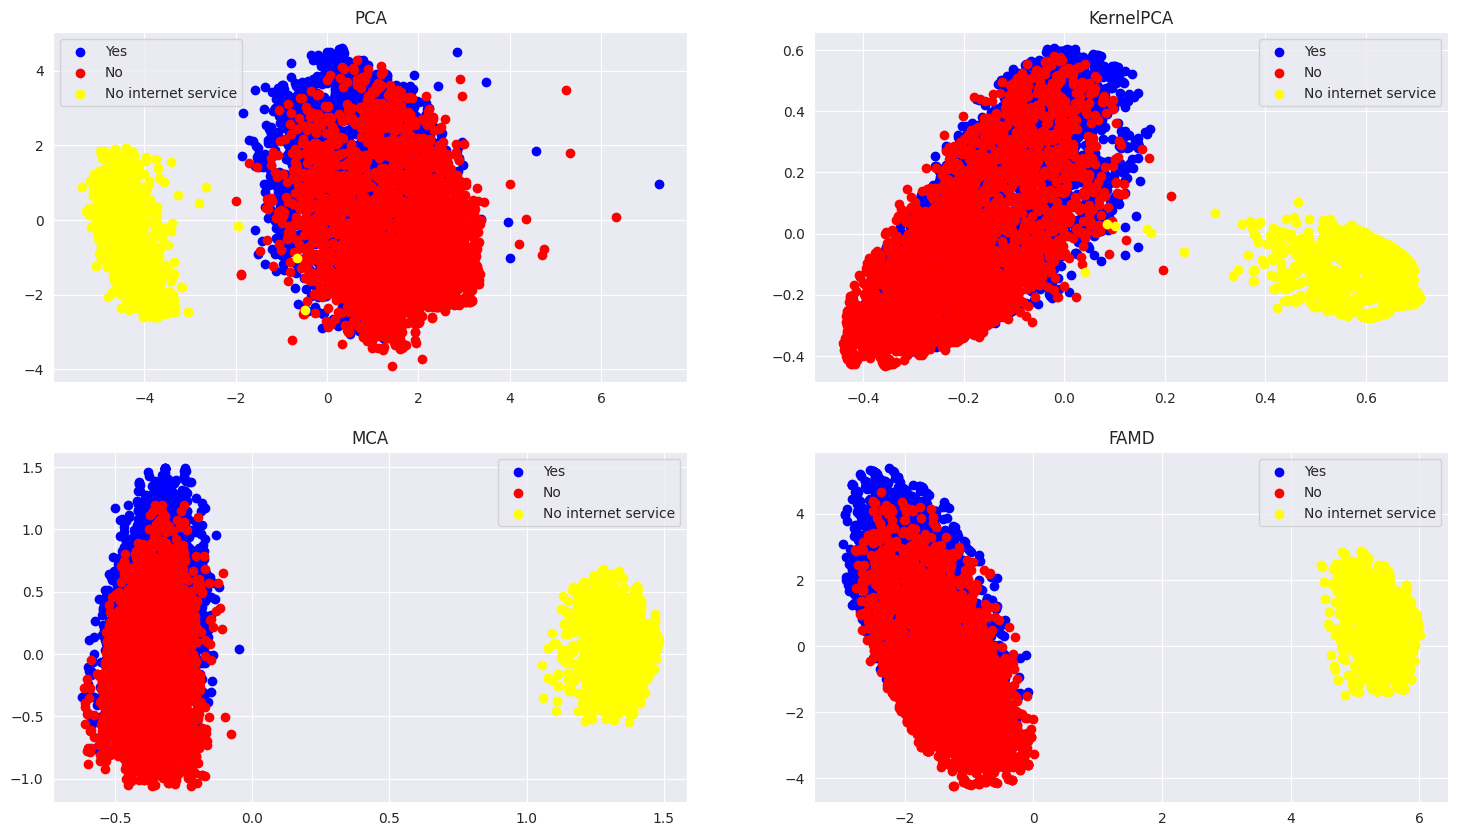

In [9]:
plot_scatter(df, df_encoded)

Итак, в подвтерждение моей версии все 4 алгоритма выделили отдельный кластер с теми, у кого нет интернета

Итак, для тех, у кого есть интернет, добавим/видоизменим следующие признаки:
- Количество подключённых сервисов
- Надёжность онлайн-подключения и устройств
- Незащищённое оптоволокно
- Размер семьи
- Признак автоматического платежа
- Численные значения в признаке контракта
- Удаление признака итоговых затрат

In [13]:
services = [
    'PhoneService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df_internet.insert(
    df_internet.columns.get_loc('StreamingMovies') + 1,
    'NumServices',
    df_internet['MultipleLines'].eq(1).astype(int) + \
        df_internet[services].sum(axis=1)
)

df_internet.insert(
    df_internet.columns.get_loc('NumServices') + 1,
    'Security',
    (df_internet['OnlineSecurity'] + df_internet['TechSupport'] + \
     df_internet['OnlineBackup'] + df_internet['DeviceProtection']).astype(int)
)

df_internet.insert(
    df_internet.columns.get_loc('Security') + 1,
    'FiberNoProtection',
    (
        (df_internet['InternetService'] == 'Fiber optic') & \
         (df_internet['Security'] == 0)
    ).astype(int)
)

df_internet.insert(
    df_internet.columns.get_loc('Dependents') + 1,
    'FamilySize',
    df_internet['Partner'] + df_internet['Dependents']
)

df_internet.insert(
    df_internet.columns.get_loc('PaymentMethod') + 1,
    'AutoPay',
    df_internet['PaymentMethod'].isin(
        ['Bank transfer (automatic)', 'Credit card (automatic)']
    ).astype(int)
)

df_internet['Contract'] = df_internet['Contract'].replace({
    'Month-to-month': '1',
    'One year': '12',
    'Two year': '24'
}).astype(int)

df_internet = df_internet.drop(columns='TotalCharges')

df_internet = df_internet.drop(
    df_internet[
        (df_internet['Churn'] == 1) & \
        (df_internet['Tenure'] == df['Tenure'].max())
    ].index
)

/tmp/ipykernel_5141/3566675403.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_internet['Contract'] = df_internet['Contract'].replace({


Также для тех, у кого нет интернета, добавим/видоизменим следующие признаки:
- Размер семьи
- Признак автоматического платежа
- Численные значения в признаке контракта
- Удаление признака итоговых затрат

In [164]:
df_no_internet.insert(
    df_no_internet.columns.get_loc('Dependents') + 1,
    'FamilySize',
    df_no_internet['Partner'] + df_no_internet['Dependents']
)

df_no_internet.insert(
    df_no_internet.columns.get_loc('PaymentMethod') + 1,
    'AutoPay',
    df_no_internet['PaymentMethod'].isin(
        ['Bank transfer (automatic)', 'Credit card (automatic)']
    ).astype(int)
)

df_no_internet['Contract'] = df_no_internet['Contract'].replace({
    'Month-to-month': '1',
    'One year': '12',
    'Two year': '24'
}).astype(int)

df_no_internet = df_no_internet.drop(columns='TotalCharges')

df_no_internet = df_no_internet.drop(
    df_no_internet[
        (df_no_internet['Churn'] == 1) & \
        (df_no_internet['Tenure'] == df['Tenure'].max())
    ].index
)

Чтобы правильным образом разделить данные, надо сначала разбить признак времени на квантили, а потом склеить его с признаком ухода

Разбиение будет идти стратифицированно по этому новому полю

In [192]:
def split(df):
    df['time_bin'] = df.groupby('Churn')['Tenure'].transform(
        lambda x: pd.qcut(x, q=10, labels=False, duplicates='drop')
    )
    df['strata'] = (
        df['Churn'].astype(str) + '_' + df['time_bin'].astype(str)
    )
    df_train, df_test = train_test_split(
        df,
        test_size=0.25,
        stratify=df['strata']
    )
    df_train, df_test = map(
        lambda df: df.drop(columns=['time_bin', 'strata']),
        [df_train, df_test]
    )
    return df, df_train, df_test

In [193]:
df_internet, df_internet_train, df_internet_test = split(df_internet)
df_no_internet, df_no_internet_train, df_no_internet_test = split(
    df_no_internet
)

Снова запустим логранговые тесты, только теперь для тренировочной и тетовой выборок и здесь мы ожидаем значение p-value больше 0.05

In [196]:
logrank_test(
    df_internet_train['Tenure'],
    df_internet_test['Tenure'],
    observed_A=df_internet_train['Churn'],
    observed_B=df_internet_test['Churn'],
)

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
        observed_A = customerID
9919-KNPOO    0
3808-HFKDE    0
6435-VWCCY    0
2960-NKRSO    0
7471-MQPOS    0
             ..
4012-YCFAI    0
8816-VXNZD    1
0032-PGELS    1
1304-SEGFY    0
3890-RTCMS    0
Name: Churn, Length: 4129, dtype: int64
        observed_B = customerID
2824-MYYBN    0
5240-CAOYT    0
4648-YPBTM    0
0308-GIQJT    0
4501-VCPFK    0
             ..
9833-TGFHX    0
9359-UGBTK    0
3606-TWKGI    1
0237-YFUTL    0
8378-LKJAF    0
Name: Churn, Length: 1377, dtype: int64
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.07 0.79      0.33

In [197]:
logrank_test(
    df_no_internet_train['Tenure'],
    df_no_internet_test['Tenure'],
    observed_A=df_no_internet_train['Churn'],
    observed_B=df_no_internet_test['Churn'],
)

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
        observed_A = customerID
1272-ILHFG    0
1744-JHKYS    0
3061-BCKYI    0
4534-WGCIR    0
0442-TDYUO    0
             ..
9142-XMYJH    0
5884-FBCTL    0
4018-PPNDW    0
6725-TPKJO    0
8380-MQINP    0
Name: Churn, Length: 1140, dtype: int64
        observed_B = customerID
4742-TXUEX    0
4541-RMRLG    1
1735-XMJVH    0
8908-SLFCJ    0
0042-RLHYP    0
             ..
3070-FNFZQ    0
3030-ZKIWL    0
6223-DHJGV    0
1927-QEWMY    0
9392-XBGTD    0
Name: Churn, Length: 380, dtype: int64
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.00 0.98      0.02

Так, отлично, значения p-value очень большие, значит разделение было удачным

Теперь также закодируем и нормируем данные, только на сей раз сначала всё будет обучаться на тренировочной выборке и применяться к тестовой

In [201]:
def encode_and_scale(
    df_train,
    df_test,
    time='Tenure',
    event='Churn'
):
    categorical_columns = df_train.select_dtypes(exclude='number').columns
    encoder = CountEncoder()
    df_train[categorical_columns] = encoder.fit_transform(
        df_train[categorical_columns]
    )
    df_test[categorical_columns] = encoder.transform(df_test[categorical_columns])

    feature_columns = df_train.drop(columns=[time, event]).columns
    scaler = StandardScaler()
    df_train[feature_columns] = scaler.fit_transform(df_train[feature_columns])
    df_test[feature_columns] = scaler.transform(df_test[feature_columns])
    return df_train, df_test

In [202]:
df_train_internet, df_test_internet = encode_and_scale(
    df_internet_train,
    df_internet_test
)
df_train_no_internet, df_test_no_internet = encode_and_scale(
    df_no_internet_train,
    df_no_internet_test
)

Теперь выделим предикторы и целевую переменную

In [206]:
def get_regressors_and_target(df, time='Tenure', event='Churn'):
    X = df.drop(columns=[time, event])
    y_struct = Surv.from_arrays(
        event=df[event].astype(bool),
        time=df[time]
    )
    return X, y_struct

In [207]:
X_train_internet, y_train_internet = get_regressors_and_target(
    df_train_internet
)
X_test_internet, y_test_internet = get_regressors_and_target(df_test_internet)

X_train_no_internet, y_train_no_internet = get_regressors_and_target(
    df_train_no_internet
)
X_test_no_internet, y_test_no_internet = get_regressors_and_target(
    df_test_no_internet
)

# Обучение

Теперь рассмотрим классическую модель для решения задачи time-to-event - модель Кокса

Идея модели — риск события в момент $\large{t}$ для объекта с признаками $\large{x}$ представляется как произведение двух независимых частей:

$$\large{h(x|t)=h_0(t)\cdot e^{\beta^T x},}$$
где:
- $\large{h(t|x)}$ — hazard rate: мгновенная интенсивность наступления события в момент $\large{t}$, при условии что объект дожил до $\large{t}$
- $\large{h_0(t)}$ — базовый риск (baseline hazard) — произвольная, не заданная заранее функция времени, общая для всех объектов
- $\large{\beta}$ — вектор коэффициентов модели (то, что модель выучивает)
- $\large{e^{\beta^T x}}$ — мультипликативный "множитель риска", зависящий только от признаков, но не от времени

Модель называется полупараметрической - часть модели (эффект признаков $\large{e^{\beta^T x}}$) параметрическая — задаётся конечным числом параметров $\large{\beta}$. А вот $\large{h_0(t)}$ — совершенно свободная функция времени, её форма не постулируется заранее. Это ключевое отличие Кокса от параметрических моделей

Возьмём отношение рисков двух разных объектов $\large{x_1}$ и $\large{x_2}$ в один и тот же момент времени:

$$\large{\frac{h(x_1|t)}{h(x_2|t)}=\frac{h_0(t)\cdot e^{\beta^T x_1}}{h_0(t)\cdot e^{\beta^T x_2}}=e^{\beta^T\left(x_1-x_2\right)}}$$

То есть отношение рисков между объектами не зависит от времени $\large{t}$ и постоянно на всём горизонте наблюдения

Итак, если бы мы хотели написать обычное правдоподобие (плотность $\large{f(t|x)}$ для каждого объекта), нам пришлось бы задать $\large{h_0(t)}$ явно, но тогда это была бы уже параметрическая модель

Решение, предложенное Коксом, заключается в том, чтобы оценивать вектор $\large{\beta}$ без оценивания базовой функции $\large{h_0(t)}$ - учитывая, что в момент $\large{t_i}$ произошло ровно одно событие среди всех ещё живых объектов — какова вероятность, что это случилось именно с объектом $\large{i}$, а не с кем-то другим из живых

Формула частичного правдоподобия оценивается следующим образом:
$$\large{\mathcal{L}(\beta)=\prod_{i:\delta_i=1}}\frac{\beta^T x_i}{\sum_{j \in R_{t_i}}e^{\beta^T x_j},}$$
где:
- $\large{\delta_i = 1}$ означает наличие события, то есть произведение берётся только по тем объектам, у которых реально произошло событие
- $\large{R_{t_i}}$ - множество риска в момент $\large{t_i}$: множество всех объектов, которые ещё "живы" (не выбыли и не случилось событие) непосредственно перед моментом $\large{t_i}$. В него входят и будущие события, и будущие цензуры — все, кто дожил до этого момента
- $\large{e^{\beta^T x_i}}$ - "вес риска" объекта $\large{i}$, с которым у него реально произошло событие
- $\large{\sum_{j \in R_{t_i}}e^{\beta^T x_j}}$ - сумма "весов риска" всех, кто мог бы получить событие в этот момент

Дробь $\large{\frac{\beta^T x_i}{\sum_{j \in R_{t_i}}e^{\beta^T x_j}}}$ — это как бы "вероятность того, что именно объект $\large{i}$ выиграл лотерею на событие в момент $\large{t_i}$, при условии, что кто-то из множества риска его точно получил". Модель обучается так, чтобы у тех, с кем событие реально случилось, эта условная "вероятность выигрыша" была максимальной по сравнению с остальными претендентами из множетва риска

Цензурированный объект никогда не появляется как $\large{i}$ в числителе (для него нет "момента $\large{t_i}$, где произошло событие"), но он обязательно входит в $\large{R_{t_j}}$ для всех более ранних моментов $\large{t_j}$ ≤ его собственного времени цензуры — он "конкурирует" за событие, отдавая знание "я был жив и мог бы получить событие, но не получил (по крайней мере, до момента, когда выбыл)". Это и есть механизм, с помощью которого модель Кокса корректно использует всю доступную информацию, включая неполную

Как и во многих таких случаях, оптимизируется отрицательный логарифм правдоподобия:
$$\large{-\log\mathcal{L}(\beta)=\sum_{i:\delta_i=1}\left[\beta^Tx_i-\sum_{j \in R_{t_i}}\beta^Tx_j\right]}$$

После обучения модель предсказывает значение мгновенного риска для каждого объекта:
$$\large{risk(x)=e^{\beta^Tx}}$$

$\large{h_0(t)}$ не оценивалась при максимизации частичного правдоподобия, её нужно восстановить отдельно, постфактум, зная уже подобранные $\large{\hat{\beta}}$. Это делает оценка Бреслоу — непараметрическая оценка кумулятивного базового риска:
$$\large{\hat{H_0}(t)=\sum_{t_i \leq t}\frac{d_{t_i}}{\sum_{j \in R_{t_i}}e^{\beta^Tx_j}},}$$
где:
- $\large{d_{t_i}}$ - число событий, произошедшее в момент времени $\large{t}$

Далее кумулятивный риск вычисляется следующим образом:
$$\large{\hat{H}(x|t)=\hat{H_0}(t)\cdot e^{\beta^Tx}}$$

Это формула функции выживания:
$$\large{\hat{S}(x|t)=e^{-\hat{H}(x|t)}=e^{-\hat{H_0}(t)\cdot e^{\beta^Tx}}}$$

Ну а ожидаемое время события вычисляется через интеграл:
$$\large{E\left[T\right]}=\int_0^\infty S\left[x|t\right]dt$$

Теперь разберём модель градиентного бустинга, которая обучается с такой же функцией потерь, как и в модели Кокса

Используется та же структурная форма, что и у модели Кокса:
$$\large{h(x|t)=h_0(t)\cdot e^{f(x)}}$$

Главное отличие - вместо линейного предиктора $\large{\beta^Tx}$ используется сумма множества деревьев решений $\large{f(x)}$:
$$\large{f(x)=\sum_{i=1}^M \eta_i\cdot tree_i(x),}$$
где:
- $\large{M}$ - число деревьев в ансамбле
- $\large{\eta_i}$ - темп обучения на шаге $\large{i}$
- $\large{tree_i(x)}$ - предсказание $\large{i}$-ого дерева

Минимизируется тот же самый логарифм правдоподобия:
$$\large{-\log\mathcal{L}(\beta)=\sum_{i:\delta_i=1}\left[f(x_i)-\sum_{j \in R_{t_i}}f(x_j)\right]}$$

Раз $\large{f(x)}$ нелинейна и представлена ансамблем деревьев, метод Ньютона-Рафсона (который использовался для $\large{\beta}$ в модели Кокса) здесь напрямую неприменим — нужен другой механизм оптимизации: функциональный градиентный спуск

Итак, общая идея бустинга следующая:
1) На первом шаге инициализируем $\large{f_0(x)}$ какой-нибудь константой
2) На каждой итерации вычисляем псевдоостатки (отрицательный градиент лосса по значению $\large{f(xᵢ)}$, в точке текущего ансамбля $\large{f_{m-1}}$):
$$\large{g_i^{(m)}=\delta_i-\sum_{k: i \in R_{t_k}}\frac{e^{f_{m-1}(x_i)}}{\sum_{j\in R_{t_k}}e^{f_{m-1}(x_j)}}}$$
3) Обучается обычное регресионное решающее дерево на предсказание псевдоостатков $\large{g_i^{(m)}}$
4) Значение ансамбля обновляется:
$$\large{f_m(x)=f_{m-1}(x)+\eta_m \cdot tree_m(x)}$$

После обучения модель предсказывает значение мгновенного риска для каждого объекта:
$$\large{risk(x)=e^{f(x)}}$$

Формула оценик Бреслоу остаётся той же самой:
$$\large{\hat{H_0}(t)=\sum_{t_i \leq t}\frac{d_{t_i}}{\sum_{j \in R_{t_i}}e^{f(x_j)}},}$$
где:
- $\large{d_{t_i}}$ - число событий, произошедшее в момент времени $\large{t}$

Далее кумулятивный риск вычисляется следующим образом:
$$\large{\hat{H}(x|t)=\hat{H_0}(t)\cdot e^{f(x)}}$$

Это формула функции выживания:
$$\large{\hat{S}(x|t)=e^{-\hat{H}(x|t)}=e^{-\hat{H_0}(t)\cdot e^{f(x)}}}$$

Ну а ожидаемое время события вычисляется через интеграл:
$$\large{E\left[T\right]}=\int_0^\infty S\left[x|t\right]dt$$

In [174]:
def get_times(
    df_test,
    time_column='Tenure',
    epsilon=1e-9,
    n_timesteps=150
):
    return np.linspace(
        df_test[time_column].min(),
        df_test[time_column].max() - epsilon,
        n_timesteps
    )

def predict_concordance(
    df_test,
    risk_scores,
    event_column='Churn',
    time_column='Tenure'
):
    concordance = concordance_index_censored(
        df_test[event_column].astype(bool),
        df_test[time_column],
        risk_scores,
    )[0]
    return concordance

def predict_concordance_ipcw(
    y_train_struct,
    y_test_struct,
    risk_scores
):
    concordance_ipcw = concordance_index_ipcw(
        y_train_struct,
        y_test_struct,
        risk_scores
    )[0]
    return concordance_ipcw

def predict_dynamic_auc(
    y_train_struct,
    y_test_struct,
    risk_scores,
    times
):
    dynamic_auc = cumulative_dynamic_auc(
        y_train_struct,
        y_test_struct,
        risk_scores,
        times
    )[0]
    mean_auc = np.nanmean(dynamic_auc)
    return mean_auc

def predict_integrated_brier_score(
    y_train_struct,
    y_test_struct,
    survival_functions,
    times
):
    ibs = integrated_brier_score(
        y_train_struct,
        y_test_struct,
        survival_functions,
        times
    )
    return ibs

Итак, мы будем обучать модель XGBoost на функцию потерь из модели Кокса, однако эта модель не будет финальной. Из неё мы извлечём эмббеддинги (номера листов, в которые попали объекты), а потом закодируем их с помощью One-hot кодировщика. Затем для полученных тренировочных и тестовых эмбеддингов обработаем 2 различными способами

В первом способе мы для каждого тестового эмбеддинга с помошью метода ближайшего соседа и метрики Хэмминга найдём в тренировочной выборке несколько наиболее похожих на него объектов, для которых построим обычную модель Каплана-Майера. Схематично это представлено на следующем рисунке

![](https://towardsdatascience.com/wp-content/uploads/2021/02/1BiZ4P0pOVjNeHlDz3-ZyOg-1024x358.png)

In [152]:
def get_survival_curve_knn(
    query_embedding,
    embedding_train,
    T_train,
    E_train,
    times,
    n_neighbors=30,
    metric='hamming'
):
    nn = NearestNeighbors(n_neighbors=n_neighbors, metric=metric)
    nn.fit(embedding_train)
    _, neighbor_idx = nn.kneighbors(query_embedding)

    curves = []
    for neighbors in tqdm(neighbor_idx):
        kmf = KaplanMeierFitter()
        kmf.fit(T_train.values[neighbors], E_train.values[neighbors])
        curves.append(kmf.survival_function_at_times(times).values)
    return np.array(curves)

В втором способе для каждого интервала времени мы обучим логистическую регрессию предсказывать, что событие произойдёт конкретно в этом интервале. Причём обучение будт просиходить только на тех объектах, которе не выбыли до начала интервала. Таким образом мы получим значения функции мгновенного риска $\large{h(t)}$ для тестовых данных

Чтобы получить значения функции выживания $\large{S(t)}$, надо для каждого объекта кумулятивно перемножить разность единицы и значения мгновенного риска. Схема представлена на следующем изображении:
![](https://towardsdatascience.com/wp-content/uploads/2021/02/1ktqm81oXDxt3Vd0eBZioAw-1024x358.png)

Для более полного ознакомления можно прочитать следующую статью, где приведены все эти модели - https://towardsdatascience.com/xgbse-improving-xgboost-for-survival-analysis-393d47f1384a/

In [186]:
def fit_conditional_hazard_classifiers(
    embedding_train,
    T_train,
    E_train,
    times
):
    T_train = np.asarray(T_train.values, dtype=np.float64)
    E_train = np.asarray(E_train.values, dtype=np.float64)
    classifiers = []
    interval_starts = np.concatenate([[0.0], times[:-1]])

    for k, (t_start, t_end) in tqdm(enumerate(zip(interval_starts, times))):
        at_risk = T_train >= t_start
        T_risk = T_train[at_risk]
        E_risk = E_train[at_risk]
        embedding_risk = embedding_train[at_risk]

        event_in_interval = (
            (T_risk >= t_start) & (T_risk < t_end) & (E_risk == 1)
        )
        survived_through = T_risk >= t_end

        usable = event_in_interval | survived_through
        y_k = event_in_interval[usable].astype(int)
        X_k = embedding_risk[usable]

        clf = LogisticRegression(max_iter=2000, C=1.0)
        if len(np.unique(y_k)) < 2:
            clf = None
        else:
            clf.fit(X_k, y_k)
        classifiers.append(clf)
    return classifiers

def predict_survival_from_hazards(embedding_test, classifiers):
    n_test = embedding_test.shape[0]
    n_times = len(classifiers)
    hazards = np.zeros((n_test, n_times))

    for k, clf in tqdm(enumerate(classifiers)):
        if clf is None:
            hazards[:, k] = 0.0
        else:
            hazards[:, k] = clf.predict_proba(embedding_test)[:, 1]

    survival = np.cumprod(1 - hazards, axis=1)
    return survival, hazards

Теперь поговорим о том, как измерять качество полученных моделей. Для этого существует набор метрик

Первая из них, Concordance, высчитывает долю сравнимых пар объектов, для которых модель правильно ранжирует риск (объект с меньшим временем до события должен иметь более высокий предсказанный риск)

Пусть:
- $\large{N}$ - общее число объектов
- $\large{\delta_i}$ - индикатор события
- $\large{t_i}$ - время до события
- $\large{r_i}$ - предсказанный моделью риск события

Тогда индекс вычисляется следующим образом:
$$\large{C=\frac{\sum_{i=1}^N\sum_{j=1}^N \delta_i\cdot \mathbb{I}\left(t_i < t_j\right)\cdot\left[\mathbb{I}\left(r_i > r_j\right) + 0.5\cdot\mathbb{I}\left(r_i = r_j\right)\right]}{\sum_{i=1}^N\sum_{j=1}^N \delta_i\cdot \mathbb{I}\left(t_i < t_j\right)}}$$

Метрика принимает значение от 0 до 1 и чем больше, тем качественне считается ранжирование. Причём тольо ранжирование и учитывается, а вот абсолютные значения рисков - нет

Следующая метрика, Concordance IPCW, решает главную проблему предыдущего случая - он смещен при высоком уровне цензурирования. IPCW-версия использует обратные веса цензурирования, чтобы "восстановить" потерянную информацию

Формула следующая:
$$\large{C_{IPCW}=\frac{\sum_{i=1}^N\sum_{j=1}^N \delta_i\cdot \mathbb{I}\left(t_i < t_j\right)\cdot\frac{1}{\hat{G}^2(t_i)}\mathbb{I}\left(r_i > r_j\right)}{\sum_{i=1}^N\sum_{j=1}^N \delta_i\cdot\mathbb{I}\left(t_i < t_j\right)\cdot\frac{1}{\hat{G}^2(t_i)}},}$$
где:
- $\large{\hat{G}(t)}$ - оценка выживаемости для цензурирования (то есть вероятность не быть цензурированным до момента $\large{t}$). Оценивается через Каплана-Майера, где "событием" считается цензурирование
- Вес $\large{\frac{1}{\hat{G}^2(t)}}$ применяется к обоим объектам пары

Если в данных много цензурирования, обычный Concordance отбрасывает много пар как "несравнимые". IPCW-версия "взвешивает" оставшиеся пары так, как если бы цензурирования не было. Это дает несмещенную оценку даже при высоком проценте цензурирования

Следующая метрика - динамический AUC. Аналог ROC-AUC, но для конкретной точки времени $\large{t}$. Отвечает на вопрос: "Насколько хорошо модель отличает тех, у кого событие наступит до $\large{t}$, от тех, у кого оно наступит после $\large{t}$?"

Формула для конкретного момента времени $\large{t}$ выглядит следующим образом:
$$\large{AUC(t)=\frac{\sum_{i:t_i \leq t}\sum_{j:t_j > t}\delta_i\cdot\frac{1}{\hat{G}^2(t_i)}\cdot\mathbb{I}\left[r_i > r_j\right]}{\sum_{i:t_i \leq t}\sum_{j:t_j > t}\delta_i\cdot\frac{1}{\hat{G}^2(t_i)}}}$$

А затем это значение просто усреднялось по всем временам $\large{t}$. Значение метрики в пределах от 0 до 1, и чем больше, тем лучше

Можно использовать (как уже было показано) для конкретного периода времени, если он очень сильно важен

Последняя функция в ряду - Integrated Brier score, но для начала рассмотрим обычный Brier Score в отдельный момент времени $\large{t}$ с помощью предсказанных значений функции выживания $\large{S(X|t)}$:
$$\large{BS(t)=\frac{1}{N}\sum_{i=1}^N\left[S(X_i|t)^2\cdot\frac{\delta_i\cdot\mathbb{I}(t_i \leq t)}{\hat{G}(t_i)}+(1-S(X_i|t))^2\cdot\frac{\mathbb{I(t_i > t)}}{\hat{G}(t_i)}\right]}$$

Дальше интегрируем по времени и получаем Integrated Brier score (IBS):
$$\large{IBS=\frac{1}{t_{max}-t_{min}}\int_{t_{min}}^{t_{max}}BS(t)dt}$$

Метрика IBS оценивает и дискриминацию, и калибровку предсказанных вероятностей и чем ниже её значение, тем лучше (в идеале 0)

In [228]:
бычныdef get_metrics(
    df_test,
    risk_scores,
    survival_functions,
    y_train,
    y_test,
    times
):
    print(f'Concordance: {predict_concordance(df_test, risk_scores)}')
    print(f'Concordance IPCW: {predict_concordance_ipcw(y_train, y_test, risk_scores)}')
    print(f'Dynamic AUC: {predict_dynamic_auc(y_train, y_test, risk_scores, times)}')
    print(f'Integrated Brier score: {predict_integrated_brier_score(y_train, y_test, survival_functions, times)}')

С помощью этой функции можно построить точечную диаграмму для значений рисков из 2 моделей

In [209]:
def scatterplot_risk_scores(
    risk_scores_knn,
    risk_scores_logreg,
    figsize=(12, 6)
):
    ax = plt.subplots(figsize=(12, 6))[1]
    ax.scatter(risk_scores_knn, risk_scores_logreg, color='blue')
    ax.plot(
        [risk_scores_knn.min(), risk_scores_knn.max()],
        [risk_scores_knn.min(), risk_scores_knn.max()],
        color='red'
    )
    ax.set_xlabel('KNN')
    ax.set_ylabel('LogReg')
    plt.suptitle('Точечная диаграмма рисков из обеих моделей')
    plt.show()

При помощи этой функции можно визуализировать усреднённые функции выживания и сравнивать их с Капланом-Майером

In [212]:
def plot_survival_functions(
    survival_functions_knn,
    survival_functions_logreg,
    kmf_test,
    times,
    figsize=(12, 6)
):
    ax = plt.subplots(figsize=figsize)[1]
    ax.plot(kmf_test.survival_function_at_times(times), label='Kaplan-Meier')
    ax.plot(
        pd.Series(survival_functions_knn.mean(axis=0), index=times),
        label='KNN'
    )
    ax.plot(
        pd.Series(survival_functions_logreg.mean(axis=0), index=times),
        label='LogReg'
    )
    ax.legend()
    plt.suptitle('Сравнение усреднённых функций выживания с эталоном')
    plt.show()

### С интернетом

Итак, добудем для начала массив времён (он нам будет нужен для вычисления функций выживания и значений метрик)

In [236]:
times_internet = get_times(df_internet_test)

Обучим модель XGBoost

In [237]:
model_internet = XGBRegressor(
    objective='survival:cox',
    boosting_type='dart',
    eval_metric='cox-nloglik',
    tree_method='hist',
    n_estimators=1000,
    max_depth=15,
    random_state=random_state
)
model_internet.fit(
    X_train_internet,
    df_train_internet['Tenure'],
    sample_weight=df_train_internet['Churn']
)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:35:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "boosting_type" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'survival:cox'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load

Посчитаем значения SHAP и построим графики этих значений

In [238]:
explainer_internet = TreeExplainer(model_internet)
shap_values_internet = explainer_internet.shap_values(X_train_internet)

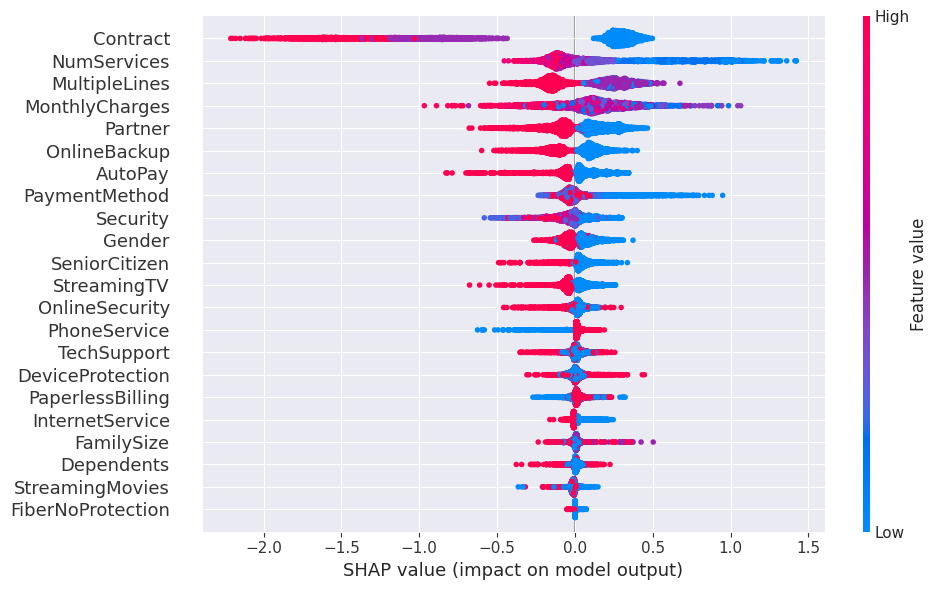

In [239]:
summary_plot(
    shap_values_internet,
    X_train_internet,
    max_display=X_train_internet.shape[1],
    plot_size=(10, 6)
)

Интерпретировать график довольно просто - синие точки означают малое значение признака, а красные - большое. Чем правее точка, тем больше шансов отказаться от услуг компании, а чем левее - тем больше шансов остаться
Можно отметить:
- Самый важный признак - контракт. Люди с долгосрочными контрактами уходят значительно реже, чем те, у кого помесячный тариф
- Количество поключ1ённых сервисов также очень сильно влияет на то, уйдёт клиент или нет. Чем меньше сервисов, тем больше шанс, что уйдёт
- Также более вероятен уход тех, кто платит вручную, чемтех, у кого платёж автоматический
- Что удивительно, более высок риск ухода тех, кто имеет телефонную связь, чем тех, кто её не имеет
- Из "персональных" признаков наиболее важен признак наличия партнёра. Более высок риск ухода "одиночек"

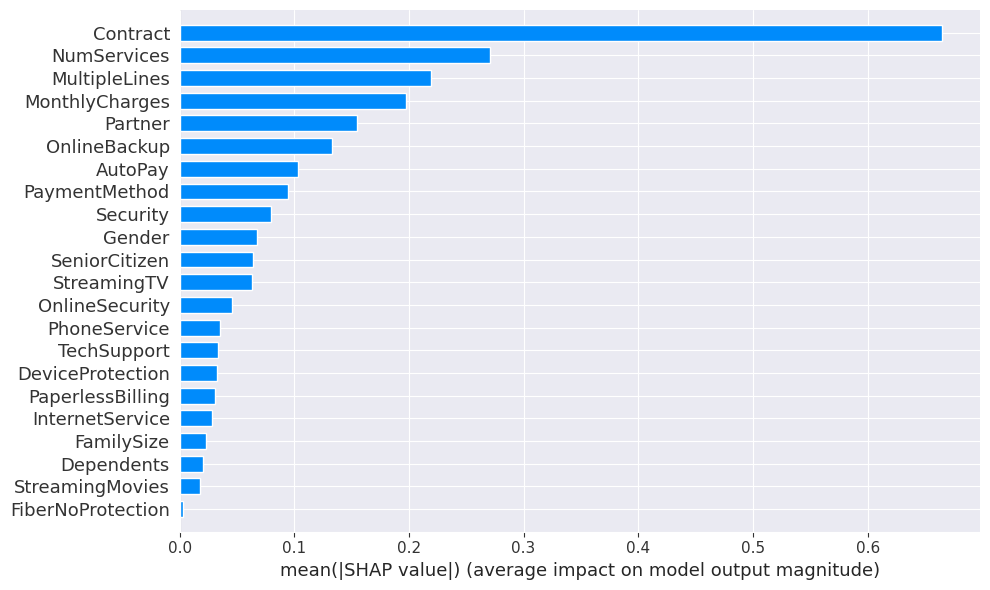

In [240]:
summary_plot(
    shap_values_internet,
    X_train_internet,
    max_display=X_train_internet.shape[1],
    plot_type='bar',
    plot_size=(10, 6)
)

Этот график просто показывает важность признков, он менее разнообразный, чем предыдущий

Итак, получим для каждлго объекта эмбеддинги - массив с номерами листьев, куда попал объект, для каждого дерева

In [260]:
leaf_indices_internet_train = model_internet.apply(X_train_internet)
leaf_indices_internet_test = model_internet.apply(X_test_internet)

Закодируем эти эмбеддинги с пмощью One-hot кодировщика

In [261]:
encoder_internet = OneHotEncoder(handle_unknown='ignore')
embedding_internet_train = encoder.fit_transform(
    leaf_indices_internet_train
).toarray()
embedding_internet_test = encoder.transform(leaf_indices_internet_test).toarray()

Итак, добудем значения функции выживания для первого способа

Ожидаемое время - это просто математическое ожидание, посчитанное с помощью значений функции выживания

Значения массива рисков - это просто отрицательные значения ожидаемых времён

In [262]:
survival_functions_internet_knn = get_survival_curve_knn(
    embedding_internet_test,
    embedding_internet_train,
    df_train_internet['Tenure'],
    df_train_internet['Churn'],
    times_internet
)

expected_time_internet_knn = np.array([
    trapezoid(row, x=times) for row in survival_functions_internet_knn
])
risk_scores_internet_knn = -expected_time_internet_knn

  0%|          | 0/1377 [00:00<?, ?it/s]

Посчитаем значения метрик

In [263]:
get_metrics(
    df_internet_test,
    risk_scores_internet_knn,
    survival_functions_internet_knn,
    y_train_internet,
    y_test_internet,
    times_internet
)

Concordance: 0.8261458707338786
Concordance IPCW: 0.8228404533237297
Dynamic AUC: 0.9118148520365496
Integrated Brier score: 0.10223592343725484


Видим, что алгоритм достаточно хорошо ранжирует объекты, а также калибровка значений функций выживания (судя по значению IBS) выполнена достаточно качественно. Но мы ещё посмотрим на график

Теперь посчитаем значения функций выживания и рисков для второго способа

In [264]:
classifiers_debiased_internet = fit_conditional_hazard_classifiers(
    embedding_internet_train,
    df_internet_train['Tenure'],
    df_internet_train['Churn'],
    times
)

survival_functions_internet_logreg = predict_survival_from_hazards(
    embedding_internet_test,
    classifiers_debiased_internet
)[0]

expected_time_internet_logreg = np.array([
    trapezoid(row, x=times) for row in survival_functions_internet_logreg
])
risk_scores_internet_logreg = -expected_time_internet_logreg

0it [00:00, ?it/s]

0it [00:00, ?it/s]

Здесь значения метрик оказались чуть получше (за исключением Concordance IPCW)

In [265]:
get_metrics(
    df_internet_test,
    risk_scores_internet_logreg,
    survival_functions_internet_logreg,
    y_train_internet,
    y_test_internet,
    times_internet
)

Concordance: 0.8351158535685653
Concordance IPCW: 0.8195212435586223
Dynamic AUC: 0.9205209288849587
Integrated Brier score: 0.1001960050280004


Построим точечный график рисков обеих моделей

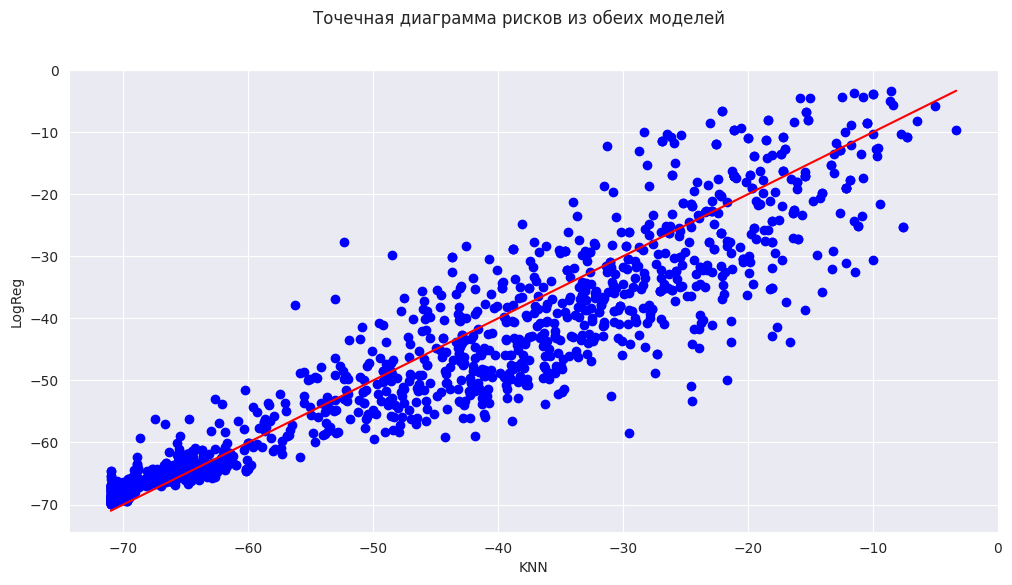

In [266]:
scatterplot_risk_scores(risk_scores_internet_knn, risk_scores_internet_logreg)

Видно, что точки в целом образуют линию (корреляция меду знаениями рисков должна быть высокой), однако значения, посчитанные с помощью логистических регресий, как будто бы чуть меньше, чем должны бы быть

Обучим эталонную модель Каплана-Майера для построения графиков функций выживания

In [267]:
kmf_internet_test = KaplanMeierFitter()
kmf_internet_test.fit(
    df_internet_test['Tenure'],
    event_observed=df_internet_test['Churn'],
    label='Kaplan-Meier'
)

<lifelines.KaplanMeierFitter:"Kaplan-Meier", fitted with 1377 total observations, 939 right-censored observations>

Теперь построим график значений функций выживания

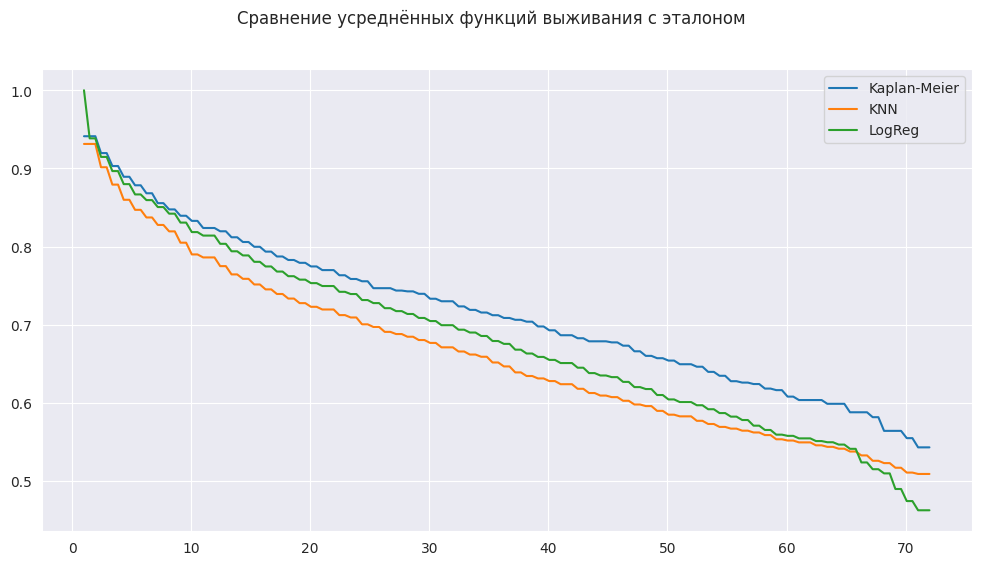

In [268]:
plot_survival_functions(
    survival_functions_internet_knn,
    survival_functions_internet_logreg,
    kmf_internet_test,
    times_internet
)

Видим, что кривые к концу начинают чуть-чуть отклоняться, однако отклонение не превышает 0.07, что является достаточно хорошим результатом (особенно по сравнению с другими моделями, которыми я пытался решать эту задачу)

### Без интернета

Ход работы будет аналогичным, поэтому комментарии я буду оставлять только после значений метрик или графиков

In [254]:
times_no_internet = get_times(df_no_internet_test)

In [255]:
model_no_internet = XGBRegressor(
    objective='survival:cox',
    boosting_type='dart',
    eval_metric='cox-nloglik',
    tree_method='hist',
    n_estimators=1000,
    max_depth=15,
    random_state=random_state
)
model_no_internet.fit(
    X_train_no_internet,
    df_train_no_internet['Tenure'],
    sample_weight=df_train_no_internet['Churn']
)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:37:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "boosting_type" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'survival:cox'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load

In [256]:
explainer_no_internet = TreeExplainer(model_no_internet)
shap_values_no_internet = explainer_no_internet.shap_values(X_train_no_internet)

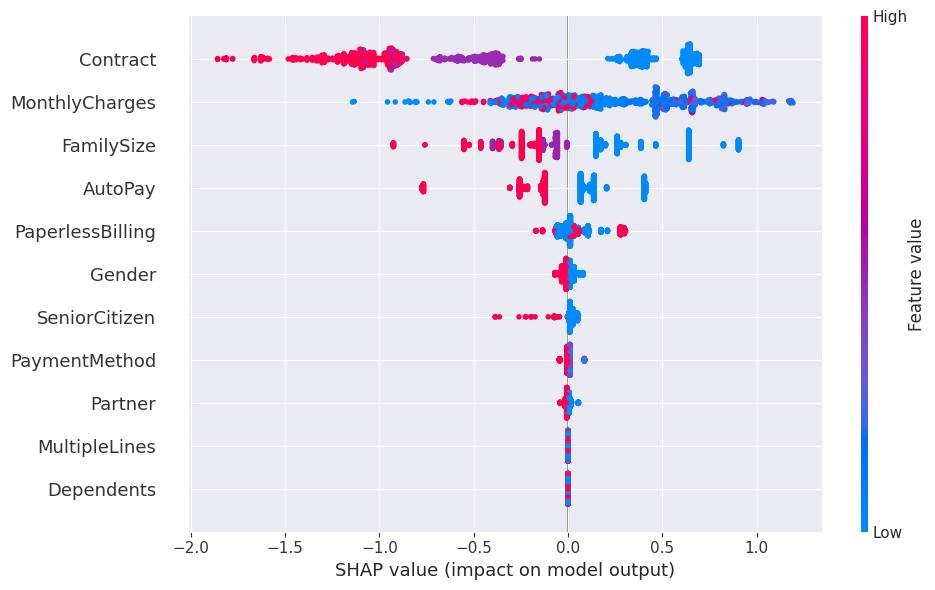

In [257]:
summary_plot(
    shap_values_no_internet,
    X_train_no_internet,
    max_display=X_train_no_internet.shape[1],
    plot_size=(10, 6)
)

Здесь наиболее определящими признакам являются признаки контракта, размера семьи и автоматического платежа. Низкие значения признаков означают более высокий риск отказа от услуг

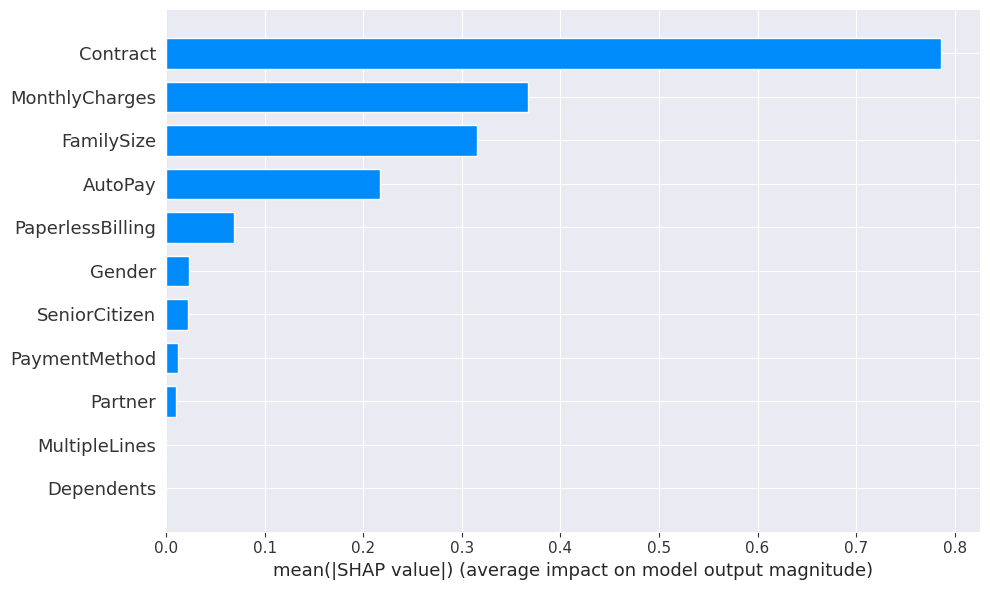

In [258]:
summary_plot(
    shap_values_no_internet,
    X_train_no_internet,
    max_display=X_train_no_internet.shape[1],
    plot_type='bar',
    plot_size=(10, 6)
)

In [269]:
leaf_indices_no_internet_train = model_no_internet.apply(X_train_no_internet)
leaf_indices_no_internet_test = model_no_internet.apply(X_test_no_internet)

In [270]:
encoder_no_internet = OneHotEncoder(handle_unknown='ignore')
embedding_no_internet_train = encoder.fit_transform(
    leaf_indices_no_internet_train
).toarray()
embedding_no_internet_test = encoder.transform(
    leaf_indices_no_internet_test
).toarray()

In [271]:
survival_functions_no_internet_knn = get_survival_curve_knn(
    embedding_no_internet_test,
    embedding_no_internet_train,
    df_train_no_internet['Tenure'],
    df_train_no_internet['Churn'],
    times_no_internet
)

expected_time_no_internet_knn = np.array([
    trapezoid(row, x=times) for row in survival_functions_no_internet_knn
])
risk_scores_no_internet_knn = -expected_time_no_internet_knn

  0%|          | 0/380 [00:00<?, ?it/s]

In [272]:
get_metrics(
    df_no_internet_test,
    risk_scores_no_internet_knn,
    survival_functions_no_internet_knn,
    y_train_no_internet,
    y_test_no_internet,
    times_no_internet
)

Concordance: 0.8251565762004175
Concordance IPCW: 0.7813541248899432
Dynamic AUC: 0.9019653007056684
Integrated Brier score: 0.05716795624457767


Значение метрик кроме IBS стало похуже, чем в предыдущих случаях. Сам IBS упал раза в 2, но у нас и данных здесь существенно меньше

In [273]:
classifiers_debiased_no_internet = fit_conditional_hazard_classifiers(
    embedding_no_internet_train,
    df_no_internet_train['Tenure'],
    df_no_internet_train['Churn'],
    times
)

survival_functions_no_internet_logreg = predict_survival_from_hazards(
    embedding_no_internet_test,
    classifiers_debiased_no_internet
)[0]

expected_time_no_internet_logreg = np.array([
    trapezoid(row, x=times) for row in survival_functions_no_internet_logreg
])
risk_scores_no_internet_logreg = -expected_time_no_internet_logreg

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [274]:
get_metrics(
    df_no_internet_test,
    risk_scores_no_internet_logreg,
    survival_functions_no_internet_logreg,
    y_train_no_internet,
    y_test_no_internet,
    times_no_internet
)

Concordance: 0.8751449779633496
Concordance IPCW: 0.819613371676331
Dynamic AUC: 0.9505579125464771
Integrated Brier score: 0.05300323229872234


Здесь значения метрик наилучшие практически во всём, даже если сравнивать с "интернетными" моделями

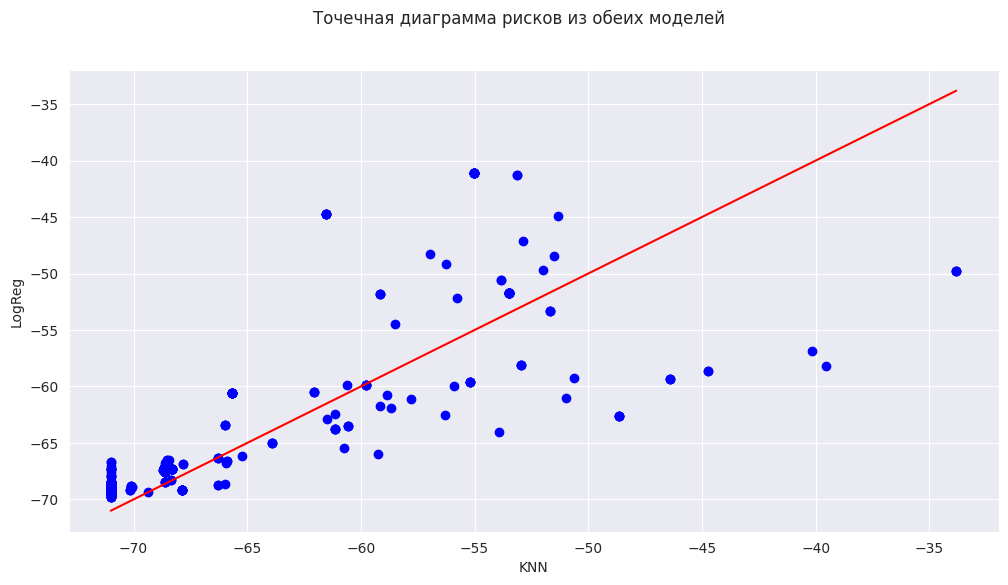

In [275]:
scatterplot_risk_scores(risk_scores_no_internet_knn, risk_scores_no_internet_logreg)

В более чем половине лучаев логистическая регрессия опять ошибается в нижнюю сторону

In [276]:
kmf_no_internet_test = KaplanMeierFitter()
kmf_no_internet_test.fit(
    df_no_internet_test['Tenure'],
    event_observed=df_no_internet_test['Churn'],
    label='Kaplan-Meier'
)

<lifelines.KaplanMeierFitter:"Kaplan-Meier", fitted with 380 total observations, 352 right-censored observations>

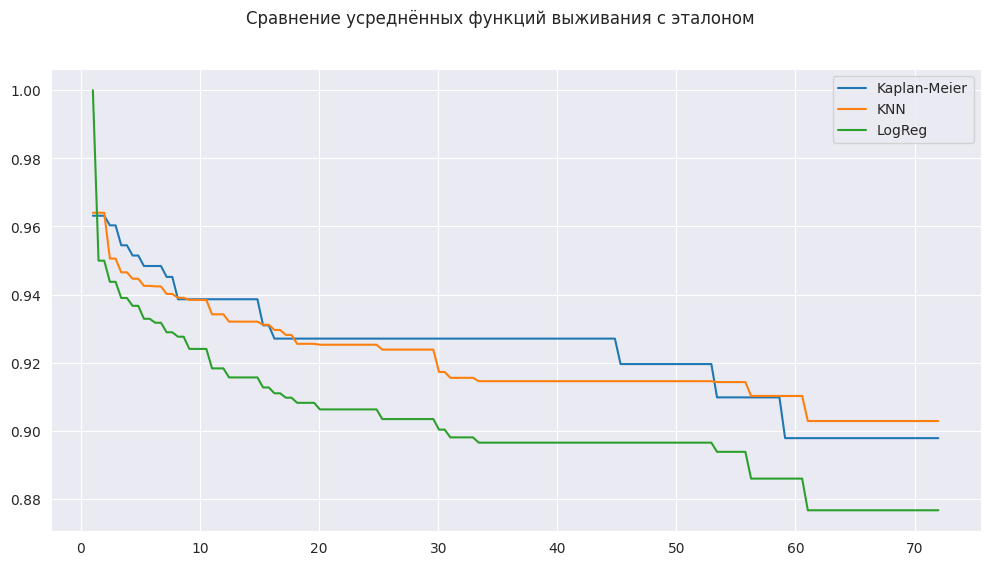

In [277]:
plot_survival_functions(
    survival_functions_no_internet_knn,
    survival_functions_no_internet_logreg,
    kmf_no_internet_test,
    times_no_internet
)

Видим, что график модели KNN значительно больше походит на эталонный, чем у модели логистической регрессии. Здесь разница уже макимум в 0.04

# Выводы

В данной лабораторной работе мной был проведён анализ имеющихся данных и были построениы модели, решающие задачу time-to-event

Использовался весьма необычный подход с обучением промежуточной модели, извлечением эмбеддингов из неё и обучением других моделей на этих эмбеддингах. Сделано это было затем, что обычные подходы давали здесь неудовлетворительное качество, если судить по значениям функции выживания (там кривые резко уходили вниз, или наоборот, были очень завышены)